**Nikhil Sunder**  
ICSRI Research Fellow, University of Miami | Open-Source Developer  
Herbert Business School, University of Miami  
B.S.B.A. Quantitative Economics & Finance; Minor in Mathematics  

**Correspondence:** nss106@miami.edu  
**Research profiles:** [GitHub](https://github.com/nikhilxsunder) · [ORCID](https://orcid.org/0009-0007-3323-1760) · [LinkedIn](https://www.linkedin.com/in/nikhil-sunder/) · [Zenodo](https://zenodo.org/search?q=metadata.creators.person_or_org.name:%22Sunder,+Nikhil%22)  
**Software:** [PyPI](https://pypi.org/user/nikhil.sunder/) · [Anaconda](https://anaconda.org/nikhil.sunder/)

# 7. Reinforcement learning: environments and reference rules

The second stage of Hinterlang & Tänzer (2021): an agent learns an interest-rate reaction function by
interacting with an estimated economy. This notebook fixes the settings of the whole exercise, wraps
the four estimated economies as TorchRL environments, and simulates the three reference rules in each.
Notebooks `08` to `10` train one algorithm each; `11` compares them.

**Inputs:** `artifacts/data/`, `artifacts/linear/svar_restricted.json`, `artifacts/linear/tvp_anchor.json`,
`artifacts/nonlinear/narx.pt`, `artifacts/nonlinear/nssm.pt`.
**Outputs:** `artifacts/rl/config.json`, the settings every later notebook loads.

The environment, the agents and the evaluation routines are defined in `autofed.rl`; the notebooks
configure and call them.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import torch

import autofed as af
from autofed import plots, rl
from autofed.style import COLORS

nb = af.NotebookSession(
    "07_rl_environments",
    number=7,
    title="Reinforcement learning: environments and reference rules",
)

## Reinforcement-learning framework

### Methodological framing

The reinforcement-learning (RL) setup follows the two-stage architecture proposed by Hinterlang
& Tänzer (2021) in Deutsche Bundesbank Discussion Paper No. 51/2021. In the first stage, the
transition equations of the macro-economy are estimated from observable data; in the second
stage, an RL agent learns an interest-rate reaction function by interacting with the estimated
economy, treating the transition equations as a fixed environment. Stage one is handled entirely
by the linear- and non-linear-environment notebooks of this project. The four fitted environments
(restricted recursive SVAR(2), TVP-SVAR-SV, restricted NARX, and two-block NSSM) are imported as-is.

The conceptual foundations of RL are due to Bellman (1957) and Howard (1960), and the modern
algorithmic treatment is due to Sutton & Barto (2018). We implement two off-policy deep-RL
algorithms with TorchRL (Bou et al., 2023) - the Deep Deterministic Policy Gradient (DDPG)
algorithm of Lillicrap et al. (2015) and the Soft Actor-Critic (SAC) algorithm of Haarnoja
et al. (2018) - and a tabular Q-learning implementation in PyTorch that matches Watkins (1989) and
Watkins & Dayan (1992).

### Observation space (H&T eq. 9-10)

Both observation specifications are trained for every applicable cell:

$$x_t^{(1)} = (y_t, \pi_t), \qquad x_t^{(2)} = (y_t, y_{t-1}, \pi_t, \pi_{t-1}).$$

The first mirrors the Taylor (1993) information set. The second adds one lag of each macro
variable, which Hawkins et al. (2015) report produces more stabilising behaviour.

### Action space and the zero lower bound (H&T eq. 11)

Continuous-control actors and critics train most stably on actions normalised to $[-1, 1]$.
We therefore declare the action spec as $a_t \in [-1, 1]$ and map it inside the environment to
$i_t = \frac{1}{2}(a_t + 1) \cdot i_{\max}$. This realises Hinterlang & Tänzer (2021, eq. 11)
for the ZLB: the lower clip at $a = -1$ corresponds exactly to $i_t = 0$. The upper clip at
$i_{\max} = 15\%$ is a maintained assumption that is non-binding over the 1987Q3-2007Q2 training
sample.

### Reward function (H&T eq. 16, fn. 13, plus Sack-Wieland 2000 smoothing)

We adopt the quadratic mandate reward of Hinterlang & Tänzer (2021, eq. 16) augmented with the
interest-rate smoothing term of Sack & Wieland (2000):

$$r_t(x_t, i_t) = -\omega_\pi (\pi_{t+1} - \pi^*)^2 - \omega_y y_{t+1}^2 - \omega_{\Delta i} (i_t - i_{t-1})^2,$$

with $\omega_\pi = \omega_y = \omega_{\Delta i} = 0.5$ and $\pi^* = 2\%$. Footnote 13 of
Hinterlang & Tänzer (2021) augments this with a soft penalty when the squared deviations of $\pi$
or $y$ exceed 4 (i.e., when the absolute deviation exceeds 2 percentage points). The
$(\Delta i)^2$ term is not in H&T eq. 16 as written, but H&T's Table 7 explicitly reports
$\mathrm{Var}(\Delta i)$ as a model-comparison metric; without the smoothing term, the agent
learns a bang-bang policy because the restricted SVAR's coefficient on $i_{t-1}$ in the
output-gap equation is only about $-0.05$, so only large rate swings exert any control. Standard
references for the term: Sack & Wieland (2000), Woodford (2003, ch. 6), Svensson (2020).

### Episode design (H&T Section 2.2)

$M = 500$ episodes per architecture. Each episode is initialised from the empirical distribution
of the training-sample data (1987Q3 to 2007Q2), then rolled forward for up to $T = 50$ quarters;
the episode terminates early when the macro state reaches the band $1.7 < \pi_{t+1} < 2.3$ and
$|y_{t+1}| < 0.3$. The discount factor is $\gamma = 0.99$ (Svensson, 2020). Reaching the band is a
true termination (no bootstrapping); hitting $T$ is a truncation, and the value target bootstraps
through it.

### Settings

One `RLConfig` holds every hyper-parameter of notebooks `07` to `11`. **Change settings here only**: the
other notebooks load the saved copy, so the algorithms are always trained and compared under the same
reward, episode design and budget.

Saved artifacts/rl/config.json


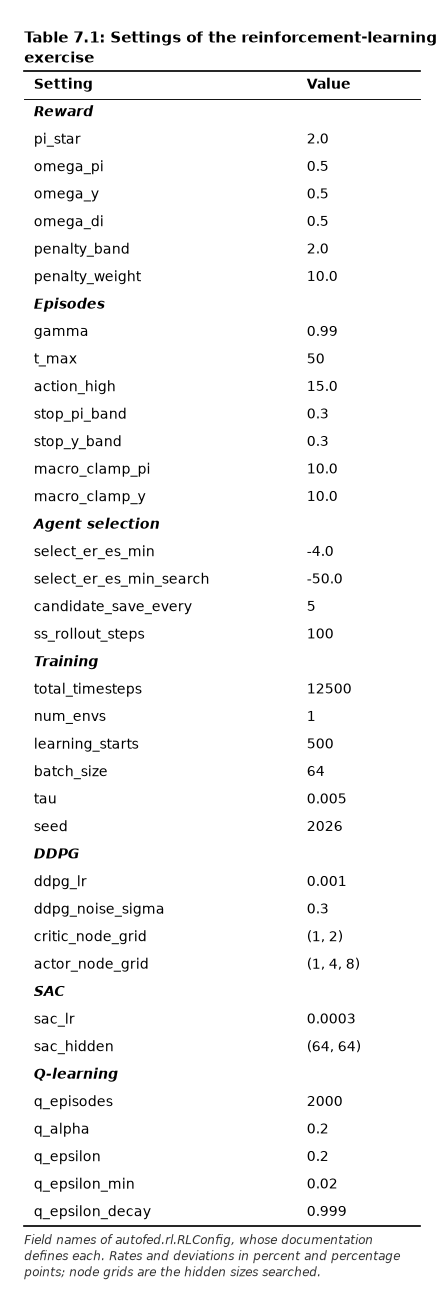

In [2]:
cfg = rl.RLConfig()
# cfg = cfg.with_full_grid()        # the paper's full 1-10 grid: about ten times the DDPG run time
print("Saved", cfg.save(nb.artifacts("rl") / "config.json").relative_to(nb.workspace.root))

GROUPS = {
    "Reward": ["pi_star", "omega_pi", "omega_y", "omega_di", "penalty_band", "penalty_weight"],
    "Episodes": [
        "gamma",
        "t_max",
        "action_high",
        "stop_pi_band",
        "stop_y_band",
        "macro_clamp_pi",
        "macro_clamp_y",
    ],
    "Agent selection": [
        "select_er_es_min",
        "select_er_es_min_search",
        "candidate_save_every",
        "ss_rollout_steps",
    ],
    "Training": ["total_timesteps", "num_envs", "learning_starts", "batch_size", "tau", "seed"],
    "DDPG": ["ddpg_lr", "ddpg_noise_sigma", "critic_node_grid", "actor_node_grid"],
    "SAC": ["sac_lr", "sac_hidden"],
    "Q-learning": ["q_episodes", "q_alpha", "q_epsilon", "q_epsilon_min", "q_epsilon_decay"],
}
assert sorted(n for names in GROUPS.values() for n in names) == sorted(cfg.__dataclass_fields__)
settings = pd.DataFrame.from_dict(
    {
        (group, name): {"Value": str(getattr(cfg, name))}
        for group, names in GROUPS.items()
        for name in names
    },
    orient="index",
)
settings.index = pd.MultiIndex.from_tuples(settings.index, names=["Group", "Setting"])
nb.table(
    settings,
    "rl_settings",
    "Settings of the reinforcement-learning exercise",
    note=(
        "Field names of autofed.rl.RLConfig, whose documentation defines each. Rates and"
        " deviations in percent and percentage points; node grids are the hidden sizes"
        " searched."
    ),
)

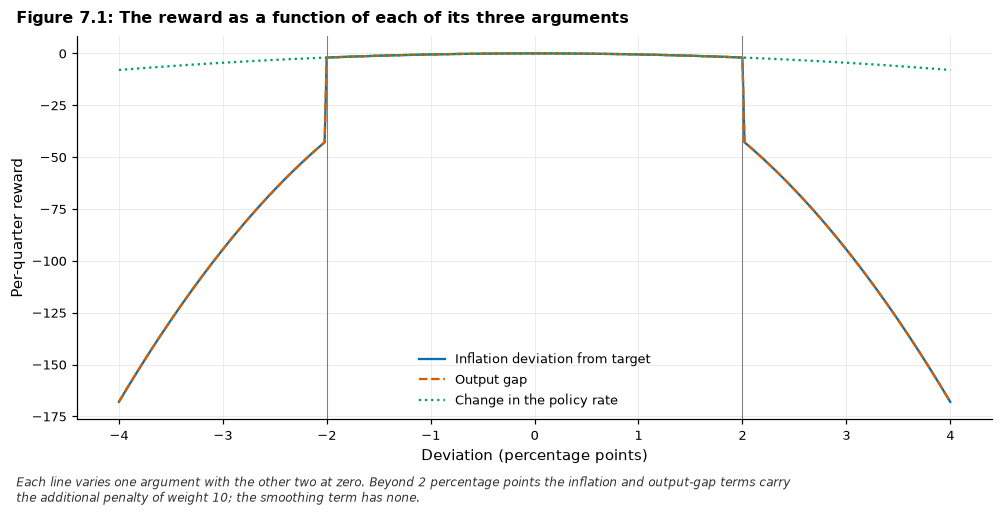

In [3]:
dev = torch.linspace(-4.0, 4.0, 401, dtype=torch.float64)
zero, target = torch.zeros_like(dev), torch.full_like(dev, cfg.pi_star)
curves = {
    "Inflation deviation from target": rl.cb_reward(cfg, cfg.pi_star + dev, zero, zero, zero),
    "Output gap": rl.cb_reward(cfg, target, dev, zero, zero),
    "Change in the policy rate": rl.cb_reward(cfg, target, zero, dev, zero),
}
fig, ax = plt.subplots()
for (label, values), style in zip(curves.items(), ("-", "--", ":")):
    ax.plot(dev.numpy(), values.numpy(), ls=style, label=label)
for edge in (-cfg.penalty_band, cfg.penalty_band):
    ax.axvline(edge, color=COLORS["grey"], lw=0.7)
ax.set_xlabel("Deviation (percentage points)")
ax.set_ylabel("Per-quarter reward")
ax.legend(loc="lower center")
nb.figure(
    fig,
    "reward_function",
    "The reward as a function of each of its three arguments",
    note=(
        f"Each line varies one argument with the other two at zero. Beyond {cfg.penalty_band:g}"
        " percentage points the inflation and output-gap terms carry the additional penalty of"
        f" weight {cfg.penalty_weight:g}; the smoothing term has none."
    ),
)

## Economy environments

Each economy is a **transition module**: a stateless, batch-first `torch.nn.Module` that maps the
lag state, the chosen rate and a pair of standard-normal draws to next quarter's
$(y_{t+1}, \pi_{t+1})$. One `MonetaryEnv`, a `torchrl.envs.EnvBase`, wraps any transition and owns
everything the economies share: the specs, the reward, the stopping band, the safety clamp and the
shock generator. The environment is itself stateless in the TorchRL sense: the lag state (and the
NSSM's latent state) travel in the TensorDict, so partial resets and any number of parallel copies
work without extra code. Truncation at $T$, the episode-return bookkeeping and the episode-start flag
are TorchRL transforms (`StepCounter`, `RewardSum`, `InitTracker`).

**Action-time convention.** When the agent at period $t$ selects action $i_t$, this rate enters
the *next* period's transition equation as the "one-quarter-lagged" rate $i_{t-1}^{(\text{next})}$,
and the previous rate $i_{t-1}$ becomes the two-quarter-lagged $i_{t-2}^{(\text{next})}$. This is
the H&T recursive identification convention: the policy rate affects $y$ and $\pi$ with at least
a one-period lag (Rotemberg & Woodford, 1997; Orphanides & Wieland, 2000).

### The four economies

Each economy is loaded from the artifact its notebook saved and wrapped as a transition module:

- **SVAR.** The restricted recursive SVAR(2) of notebook `01`; shocks have the residual standard
  deviations $\sqrt{SSR/(n-k)}$ of the two equations.
- **TVP-SVAR-SV.** The TVP-VAR-SV of notebook `03`, frozen at its posterior means at the end of the
  estimation window (Primiceri, 2005, Section 4.4). It is the same recursive linear form as the SVAR
  with different coefficients and shock scales.
- **NARX.** The two restricted networks of notebook `05` with their scalers.
- **NSSM.** The two-block neural state-space model of notebook `06`. Every episode starts from the
  latent state reached at the end of the estimation window, and the latent state travels in the
  TensorDict.

`PolicyLab` holds the four transitions, the estimation-window data that episodes start from, and the
settings; `lab.check` runs TorchRL's `check_env_specs` on each economy, single and batched.

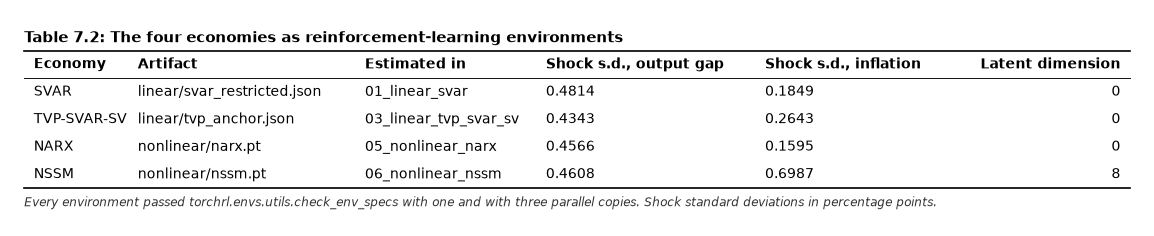

In [4]:
lab = rl.PolicyLab.load(nb.workspace.artifacts, config=cfg)
SOURCES = {
    "SVAR": ("linear/svar_restricted.json", "01_linear_svar"),
    "TVP-SVAR-SV": ("linear/tvp_anchor.json", "03_linear_tvp_svar_sv"),
    "NARX": ("nonlinear/narx.pt", "05_nonlinear_narx"),
    "NSSM": ("nonlinear/nssm.pt", "06_nonlinear_nssm"),
}
rows = {}
for name, transition in lab.transitions.items():
    lab.check(name)  # raises if an environment violates its specs
    rows[name] = {
        "Artifact": SOURCES[name][0],
        "Estimated in": SOURCES[name][1],
        "Shock s.d., output gap": float(transition.sigma[0]),
        "Shock s.d., inflation": float(transition.sigma[1]),
        "Latent dimension": transition.hidden_dim,
    }
economies = pd.DataFrame(rows).T.astype({"Latent dimension": int})
economies.index.name = "Economy"
nb.table(
    economies,
    "economies",
    "The four economies as reinforcement-learning environments",
    float_format="{:.4f}",
    note=(
        "Every environment passed torchrl.envs.utils.check_env_specs with one and with three"
        " parallel copies. Shock standard deviations in percentage points."
    ),
)

## Reference rules

Three reference rules are the baselines of every later notebook, in the level form of Hinterlang &
Tänzer (2021, Table 4), $i_t = \max\{0,\ \alpha_0 + \beta_\pi \pi_t + \beta_y y_t\}$ with
$\alpha_0 = r^* - (\beta_\pi - 1)\pi^*$ and $r^* = \pi^* = 2$. As policies they read the same
observation as a learned agent and return a normalised action.

Each rule is simulated in each economy from the first two estimation-window quarters, with the shock
sequence fixed by the seed, so every policy in every later notebook faces the same shocks within an
economy. These are simulations under freshly drawn shocks, not the historical counterfactual of
notebook `04_policy_rules`, which feeds the estimated shocks back through the economy.

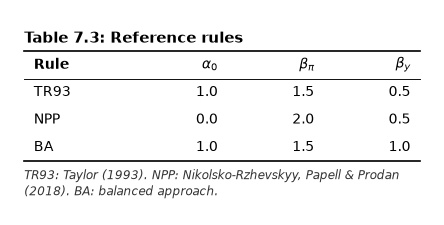

In [5]:
rules = pd.DataFrame({
    name: {
        r"$\alpha_0$": policy.rule.alpha0,
        r"$\beta_\pi$": policy.rule.beta_pi,
        r"$\beta_y$": policy.rule.beta_y,
    }
    for name, policy in lab.reference_rules().items()
}).T
rules.index.name = "Rule"
nb.table(
    rules,
    "reference_rules",
    "Reference rules",
    float_format="{:.1f}",
    note=(
        "TR93: Taylor (1993). NPP: Nikolsko-Rzhevskyy, Papell & Prodan (2018). BA: balanced"
        " approach."
    ),
)

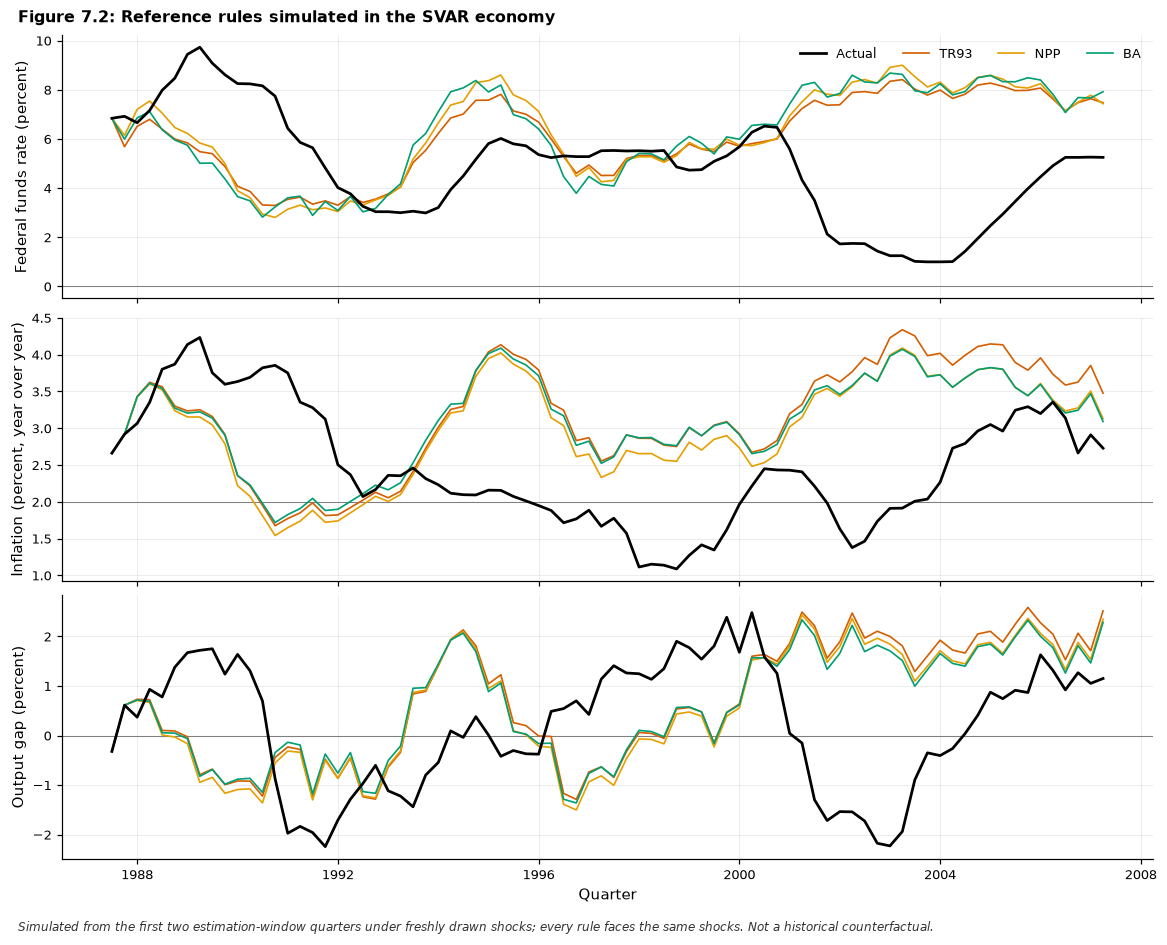

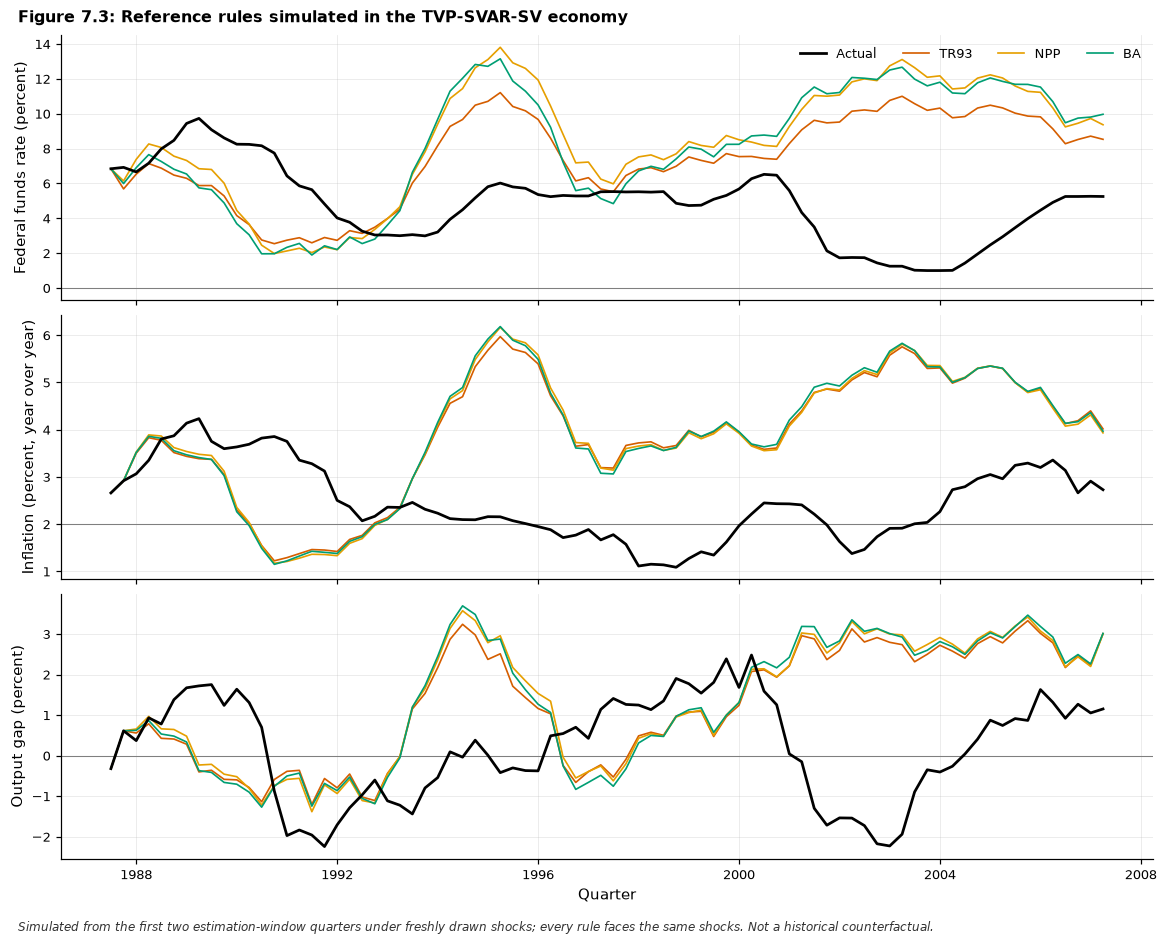

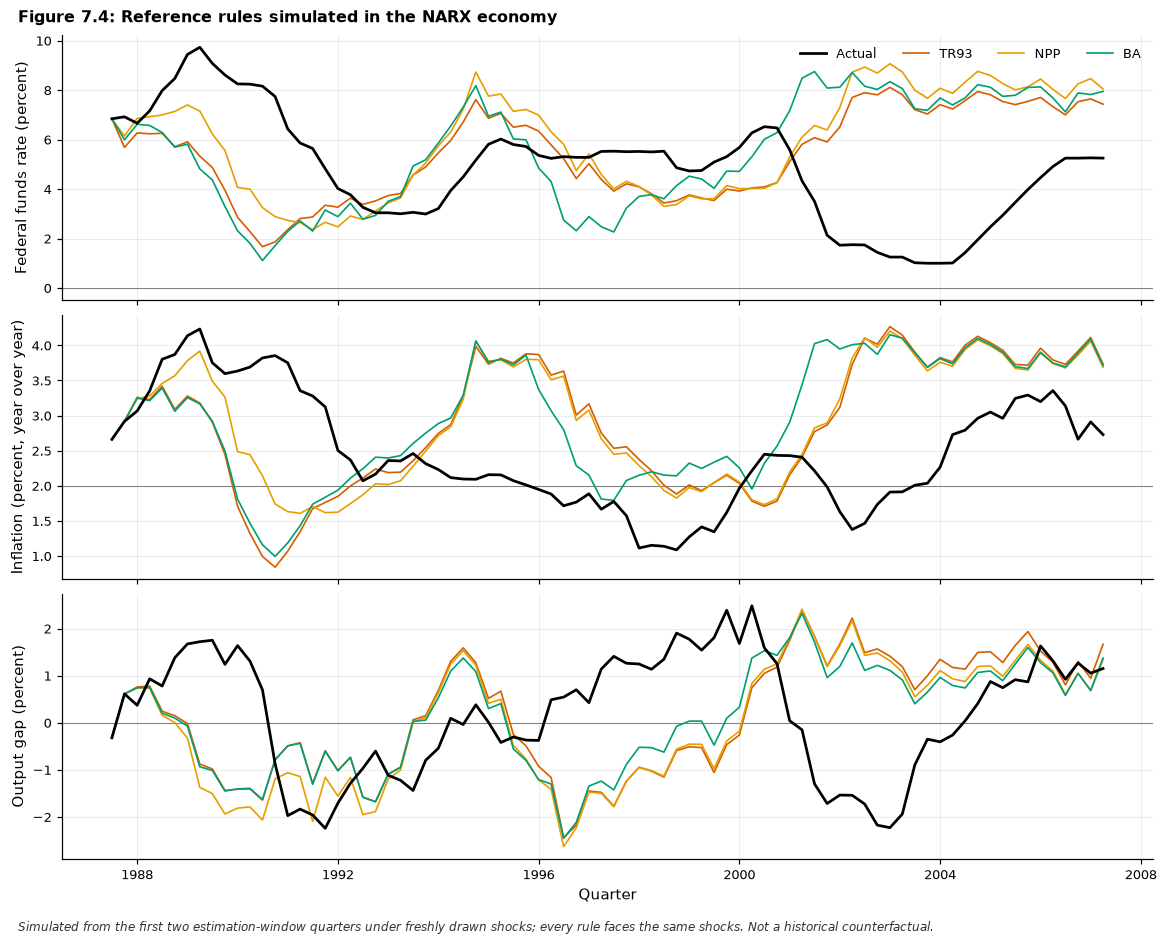

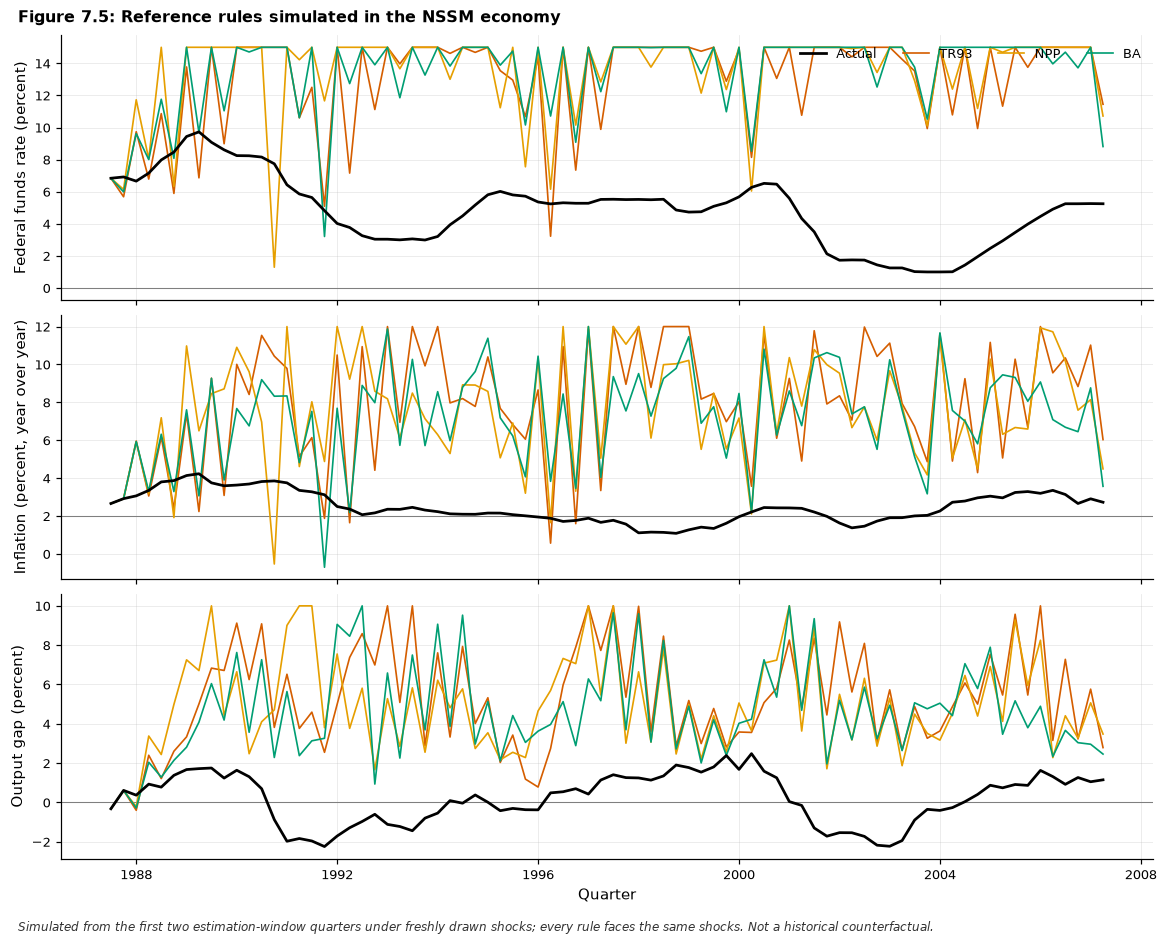

In [6]:
PATH_NOTE = (
    "Simulated from the first two estimation-window quarters under freshly drawn shocks; every"
    " rule faces the same shocks. Not a historical counterfactual."
)
paths_by_economy = {env_name: lab.simulate_policies(env_name) for env_name in lab.env_names}
for env_name, paths in paths_by_economy.items():
    fig = plots.policy_paths(paths, pi_star=cfg.pi_star)
    nb.figure(
        fig,
        f"reference_paths_{env_name.lower().replace('-', '_')}",
        f"Reference rules simulated in the {env_name} economy",
        note=PATH_NOTE,
    )

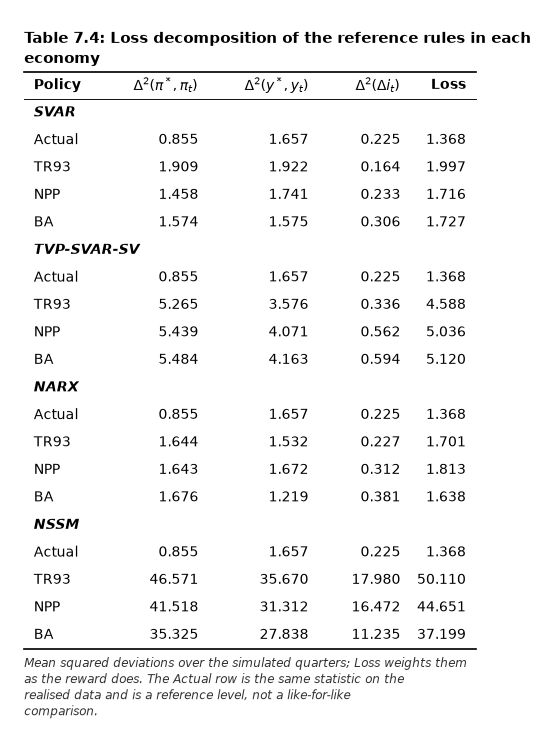

In [7]:
LOSS_COLUMNS = {
    "dev2 pi": r"$\Delta^2(\pi^*, \pi_t)$",
    "dev2 y": r"$\Delta^2(y^*, y_t)$",
    "dev2 di": r"$\Delta^2(\Delta i_t)$",
}
nb.table(
    lab.loss_table(paths_by_economy).rename(columns=LOSS_COLUMNS),
    "reference_loss",
    "Loss decomposition of the reference rules in each economy",
    note=(
        "Mean squared deviations over the simulated quarters; Loss weights them as the reward"
        " does. The Actual row is the same statistic on the realised data and is a reference"
        " level, not a like-for-like comparison."
    ),
)

# References

## 6.2 Papers and books

- Adam, K., & Billi, R. M. (2006). Optimal monetary policy under commitment with a zero bound on nominal interest rates. *Journal of Money, Credit and Banking*, 38(7), 1877-1905.
- Bellman, R. (1957). *Dynamic Programming*. Princeton University Press.
- Bou, A., Bettini, M., Dittert, S., Kumar, V., Sodhani, S., Yang, X., De Fabritiis, G., & Moens, V. (2023). TorchRL: A data-driven decision-making library for PyTorch. *arXiv preprint arXiv:2306.00577*.
- Cogley, T., & Sargent, T. J. (2005). Drifts and volatilities: Monetary policies and outcomes in the post WWII US. *Review of Economic Dynamics*, 8(2), 262-302.
- Fraccaro, M., Sonderby, S. K., Paquet, U., & Winther, O. (2016). Sequential neural models with stochastic layers. In *Advances in Neural Information Processing Systems 29* (pp. 2199-2207).
- Giacomini, R., & White, H. (2006). Tests of conditional predictive ability. *Econometrica*, 74(6), 1545-1578.
- Glorot, X., & Bengio, Y. (2010). Understanding the difficulty of training deep feedforward neural networks. In *Proceedings of the 13th International Conference on Artificial Intelligence and Statistics* (pp. 249-256).
- Goodfriend, M. (2004). Inflation targeting in the United States? In B. S. Bernanke & M. Woodford (Eds.), *The Inflation-Targeting Debate* (pp. 311-352). University of Chicago Press.
- Haarnoja, T., Zhou, A., Abbeel, P., & Levine, S. (2018). Soft actor-critic: Off-policy maximum entropy deep reinforcement learning with a stochastic actor. In *Proceedings of the 35th International Conference on Machine Learning* (Vol. 80, pp. 1861-1870).
- Hawkins, R. J., Speakes, J. K., & Hamilton, D. E. (2015). Monetary policy and PID control. *Journal of Economic Interaction and Coordination*, 10(1), 183-197.
- Hinterlang, N., & Tänzer, A. (2021). Optimal monetary policy using reinforcement learning. *Deutsche Bundesbank Discussion Paper No. 51/2021*.
- Howard, R. A. (1960). *Dynamic Programming and Markov Processes*. MIT Press.
- Krishnan, R. G., Shalit, U., & Sontag, D. (2017). Structured inference networks for nonlinear state space models. In *Proceedings of the 31st AAAI Conference on Artificial Intelligence* (pp. 2101-2109).
- Levenberg, K. (1944). A method for the solution of certain non-linear problems in least squares. *Quarterly of Applied Mathematics*, 2(2), 164-168.
- Lillicrap, T. P., Hunt, J. J., Pritzel, A., Heess, N., Erez, T., Tassa, Y., Silver, D., & Wierstra, D. (2015). Continuous control with deep reinforcement learning. *arXiv preprint arXiv:1509.02971*.
- Lucas, R. E., Jr. (1976). Econometric policy evaluation: A critique. *Carnegie-Rochester Conference Series on Public Policy*, 1, 19-46.
- Marquardt, D. W. (1963). An algorithm for least-squares estimation of nonlinear parameters. *Journal of the Society for Industrial and Applied Mathematics*, 11(2), 431-441.
- Mnih, V., Kavukcuoglu, K., Silver, D., Graves, A., Antonoglou, I., Wierstra, D., & Riedmiller, M. (2013). Playing Atari with deep reinforcement learning. *arXiv preprint arXiv:1312.5602*.
- Mnih, V., Kavukcuoglu, K., Silver, D., Rusu, A. A., Veness, J., Bellemare, M. G., Graves, A., Riedmiller, M., Fidjeland, A. K., Ostrovski, G., Petersen, S., Beattie, C., Sadik, A., Antonoglou, I., King, H., Kumaran, D., Wierstra, D., Legg, S., & Hassabis, D. (2015). Human-level control through deep reinforcement learning. *Nature*, 518(7540), 529-533.
- Nair, V., & Hinton, G. E. (2010). Rectified linear units improve restricted Boltzmann machines. In *Proceedings of the 27th International Conference on Machine Learning* (pp. 807-814).
- Nguyen, D., & Widrow, B. (1990). Improving the learning speed of 2-layer neural networks by choosing initial values of the adaptive weights. In *International Joint Conference on Neural Networks* (Vol. 3, pp. 21-26).
- Nikolsko-Rzhevskyy, A., Papell, D. H., & Prodan, R. (2018). The Taylor principles. *Journal of Macroeconomics*, 55, 14-30.
- Orphanides, A., & Wieland, V. (2000). Inflation zone targeting. *European Economic Review*, 44(7), 1351-1387.
- Primiceri, G. E. (2005). Time varying structural vector autoregressions and monetary policy. *Review of Economic Studies*, 72(3), 821-852.
- Rangapuram, S. S., Seeger, M., Gasthaus, J., Stella, L., Wang, Y., & Januschowski, T. (2018). Deep state space models for time series forecasting. In *Advances in Neural Information Processing Systems 31* (pp. 7796-7805).
- Rotemberg, J. J., & Woodford, M. (1997). An optimization-based econometric framework for the evaluation of monetary policy. *NBER Macroeconomics Annual*, 12, 297-346.
- Rudebusch, G. D., & Svensson, L. E. O. (1999). Policy rules for inflation targeting. In J. B. Taylor (Ed.), *Monetary Policy Rules* (pp. 203-262). University of Chicago Press.
- Sack, B., & Wieland, V. (2000). Interest-rate smoothing and optimal monetary policy: A review of recent empirical evidence. *Journal of Economics and Business*, 52(1-2), 205-228.
- Saxe, A. M., McClelland, J. L., & Ganguli, S. (2014). Exact solutions to the nonlinear dynamics of learning in deep linear neural networks. In *International Conference on Learning Representations*.
- Silver, D., Lever, G., Heess, N., Degris, T., Wierstra, D., & Riedmiller, M. (2014). Deterministic policy gradient algorithms. In *Proceedings of the 31st International Conference on Machine Learning* (pp. 387-395).
- Sims, C. A. (2002). Solving linear rational expectations models. *Computational Economics*, 20(1-2), 1-20.
- Sutton, R. S., & Barto, A. G. (2018). *Reinforcement Learning: An Introduction* (2nd ed.). MIT Press.
- Svensson, L. E. O. (2020). Monetary policy strategies for the Federal Reserve. *International Journal of Central Banking*, 16(1), 133-193.
- Taylor, J. B. (1993). Discretion versus policy rules in practice. *Carnegie-Rochester Conference Series on Public Policy*, 39, 195-214.
- Wang, J., Feinstein, A., & Chen, M. (2026). Reinforcement learning in monetary policy: A comparison of algorithmic approaches. *Stanford University Working Paper*.
- Watkins, C. J. C. H. (1989). *Learning from delayed rewards* (Doctoral dissertation). King's College, University of Cambridge.
- Watkins, C. J. C. H., & Dayan, P. (1992). Q-learning. *Machine Learning*, 8(3-4), 279-292.
- Wieland, V., Cwik, T., Müller, G. J., Schmidt, S., & Wolters, M. (2012). A new comparative approach to macroeconomic modeling and policy analysis. *Journal of Economic Behavior & Organization*, 83(3), 523-541.
- Wieland, V., Afanasyeva, E., Kuete, M., & Yoo, J. (2016). New methods for macro-financial model comparison and policy analysis. In J. B. Taylor & H. Uhlig (Eds.), *Handbook of Macroeconomics* (Vol. 2, pp. 1241-1319). Elsevier.
- Woodford, M. (2003). *Interest and Prices: Foundations of a Theory of Monetary Policy*. Princeton University Press.

# Export

The last cell converts this notebook to PDF in the shared `documents/` directory. A kernel can only
convert the copy saved on disk, so the cell waits briefly for the editor to save; if the file is still
behind, it writes nothing and asks you to save and run it again.

In [8]:
nb.export_pdf()

/var/folders/cj/p5jdwnb923752l7zjc_69j5w0000gn/T/ipykernel_29496/281924391.py:1: UserWarning: 07_rl_environments.ipynb on disk does not yet contain this run's outputs, so no PDF was written. Save the notebook and run this cell again.
  nb.export_pdf()
